# 05 — LDA Topic Model
**Inputs:** `data/docs_sampled.csv`, `data/hc3_VOCAB.csv`

**Outputs:** `data/hc3_LDA_THETA.csv`, `data/hc3_LDA_PHI.csv`

**Images:** `images/lda_pca.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'human':'#4C72B0', 'chatgpt':'#DD8452'}
print('Libraries loaded.')

Libraries loaded.


In [2]:
docs_sampled =pd.read_csv('../data/docs_sampled.csv')
VOCAB = pd.read_csv('../data/hc3_VOCAB.csv').set_index('term_str')
meta= docs_sampled.set_index('doc_id')[['author_type','source']]
doc_texts = docs_sampled.set_index('doc_id')['text']

print(f'Loaded {len(docs_sampled):,} documents')

Loaded 10,258 documents


## Fit LDA (nouns and verbs only)

In [3]:
noun_verb_terms = VOCAB[
    (VOCAB['max_pos_group'].isin(['NOUN','VERB'])) &
    (~VOCAB['stop']) &
    (VOCAB['n'] > 5)
].head(3000).index.tolist()

cv_lda= CountVectorizer(vocabulary=noun_verb_terms, lowercase=True, token_pattern=r'\b[a-z]+\b')
DTM_lda = cv_lda.fit_transform(doc_texts)

N_TOPICS = 10
lda =LatentDirichletAllocation(
    n_components=N_TOPICS, random_state=42,
    max_iter=20, learning_method='online'
)
lda.fit(DTM_lda)
print('LDA fitted.')

LDA fitted.


In [4]:
topic_cols= [f'T{str(i).zfill(2)}' for i in range(N_TOPICS)]
theta_vals = lda.transform(DTM_lda)
LDA_THETA = pd.DataFrame(theta_vals, index=doc_texts.index, columns=topic_cols)

phi_vals = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
LDA_PHI= pd.DataFrame(phi_vals, index=topic_cols, columns=cv_lda.get_feature_names_out())

topic_means =LDA_THETA.mean(axis=0)

print('Top 5 words per topic (by mean document weight):')
for topic in topic_cols:
    top5 = LDA_PHI.loc[topic].nlargest(5).index.tolist()
    print(f'  {topic} (mean={topic_means[topic]:.3f}): {top5}')

Top 5 words per topic (by mean document weight):
  T00 (mean=0.120): ['people', 'world', 'states', 'united', 'countries']
  T01 (mean=0.104): ['n', 'earth', 'space', 'see', 'way']
  T02 (mean=0.080): ['help', 'internet', 'information', 'use', 'healthcare']
  T03 (mean=0.066): ['company', 'price', 'stock', 'market', 'value']
  T04 (mean=0.059): ['tax', 'money', 'pay', 'credit', 'income']
  T05 (mean=0.190): ['n', 'get', 'people', 'time', 'things']
  T06 (mean=0.185): ['water', 'body', 'air', 'light', 'cause']
  T07 (mean=0.052): ['number', 'x', 'e', 'b', 'class']
  T08 (mean=0.062): ['people', 'person', 'language', 'life', 'government']
  T09 (mean=0.082): ['computer', 'use', 'used', 'data', 'system']


In [5]:
LDA_THETA.index.name = 'doc_id'
LDA_THETA.to_csv('../data/hc3_LDA_THETA.csv')
LDA_PHI.index.name = 'topic'
LDA_PHI.to_csv('../data/hc3_LDA_PHI.csv')
print('Saved LDA tables.')

Saved LDA tables.


## LDA + PCA Visualization

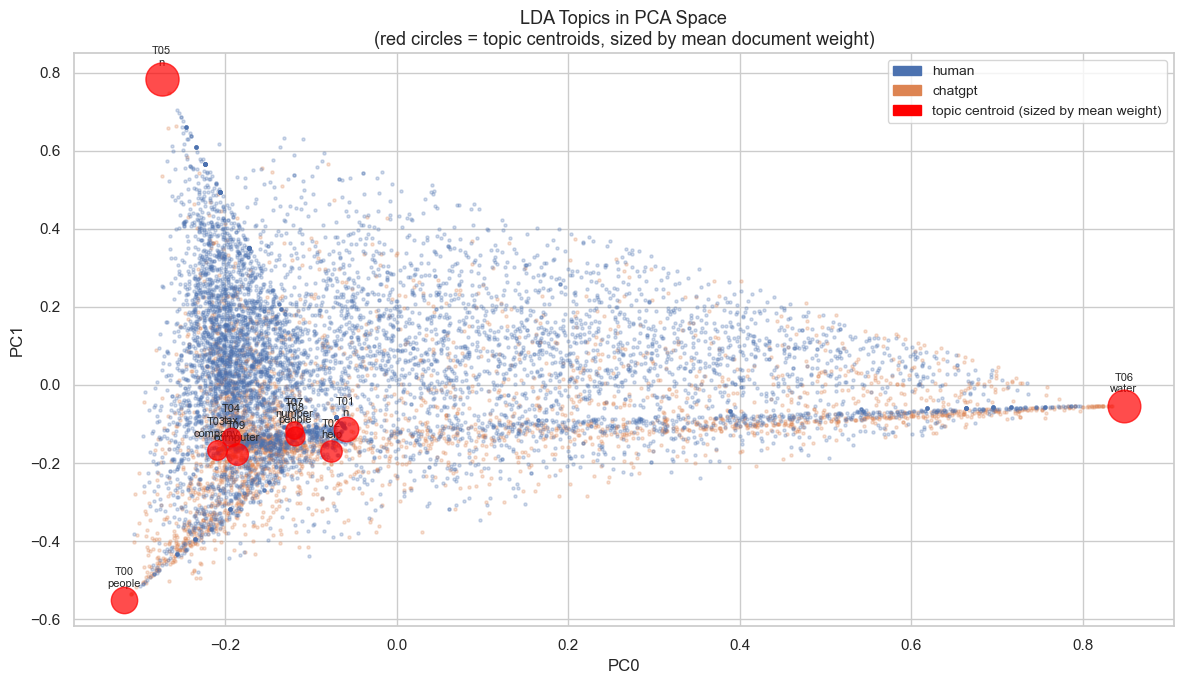

Saved images/lda_pca.png


In [6]:
pca2= PCA(n_components=2, random_state=42)
theta_pca = pca2.fit_transform(LDA_THETA.values)
doc_pca_df= pd.DataFrame(theta_pca, index=LDA_THETA.index, columns=['PC0','PC1'])
doc_pca_df = doc_pca_df.join(meta)
topic_centroids = pca2.transform(np.eye(N_TOPICS))

fig, ax =plt.subplots(figsize=(12, 7))

for atype, grp in doc_pca_df.groupby('author_type'):
    ax.scatter(grp['PC0'], grp['PC1'], c=COLORS[atype],
               label=atype, alpha=0.25, s=5)

for i, topic in enumerate(topic_cols):
    top_word = LDA_PHI.loc[topic].nlargest(1).index[0]
    size= topic_means[topic] * 3000
    ax.scatter(topic_centroids[i, 0], topic_centroids[i, 1],
               s=size, color='red', alpha=0.7, zorder=5)
    ax.annotate(f'{topic}\n{top_word}',
                (topic_centroids[i, 0], topic_centroids[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

human_patch = mpatches.Patch(color=COLORS['human'],   label='human')
chatgpt_patch = mpatches.Patch(color=COLORS['chatgpt'], label='chatgpt')
red_patch= mpatches.Patch(color='red',             label='topic centroid (sized by mean weight)')
ax.legend(handles=[human_patch, chatgpt_patch, red_patch], fontsize=10)

ax.set_title('LDA Topics in PCA Space\n(red circles = topic centroids, sized by mean document weight)', fontsize=13)
ax.set_xlabel('PC0', fontsize=12)
ax.set_ylabel('PC1', fontsize=12)
plt.tight_layout()
plt.savefig('../images/lda_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/lda_pca.png')